Andi Rayhan Wijanarko - 41523010101

In [1]:
%%capture
!pip install prophet xgboost scikit-learn tensorflow statsmodels plotly pandas numpy matplotlib seaborn python-dateutil


In [2]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from dateutil.relativedelta import relativedelta
from contextlib import contextmanager

from prophet import Prophet
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
tf.random.set_seed(42)

C = {
    'bg':'#0D1117','surface':'#161B22','grid':'#21262D',
    'text':'#E6EDF3','actual':'#58A6FF','prophet':'#3FB950',
    'sarima':'#FFA657','xgboost':'#D2A8FF','lstm':'#F78166',
    'ensemble':'#FFD700','green':'#43A047','red':'#E53935',
    'purple':'#8E24AA','teal':'#00ACC1',
}

plt.rcParams.update({
    'figure.facecolor':C['bg'],'axes.facecolor':C['surface'],
    'axes.edgecolor':C['grid'],'axes.labelcolor':C['text'],
    'xtick.color':C['text'],'ytick.color':C['text'],
    'text.color':C['text'],'grid.color':C['grid'],
    'grid.alpha':0.4,'figure.dpi':120,'font.family':'DejaVu Sans',
})

@contextmanager
def silent():
    with open(os.devnull,'w') as dn:
        old = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = dn
        try:    yield
        finally: sys.stdout, sys.stderr = old

print(f'TF {tf.__version__} | XGB {xgb.__version__} | Pandas {pd.__version__}')


TF 2.20.0 | XGB 3.2.0 | Pandas 2.2.2


In [3]:
try:
    from google.colab import files
    print('Running in Colab — upload BBRI_JK_5y_1d.csv')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
except Exception:
    CSV_PATH = 'BBRI_JK_5y_1d.csv'
    print(f'Local run: {CSV_PATH}')

df_raw = pd.read_csv(CSV_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'], utc=True).dt.tz_convert(None)
df_raw.set_index('Date', inplace=True)
df_raw.sort_index(inplace=True)
df_raw.dropna(inplace=True)
print(f'Shape: {df_raw.shape} | Range: {df_raw.index[0].date()} to {df_raw.index[-1].date()}')
df_raw.tail(3)


Running in Colab — upload BBRI_JK_5y_1d.csv


Saving BBRI.JK_5y_1d.csv to BBRI.JK_5y_1d.csv
Shape: (1201, 5) | Range: 2020-08-17 to 2025-08-14


,Open,High,Low,Close,Volume
Date,,,,,
2025-08-12 17:00:00,4060.0,4100.0,3990.0,4080.0,292104000
2025-08-13 17:00:00,4080.0,4100.0,4040.0,4060.0,164408100
2025-08-14 17:00:00,4100.0,4150.0,4070.0,4120.0,269255400


In [4]:
dm = df_raw.resample('MS').agg(
    Open=('Open','first'), High=('High','max'),
    Low=('Low','min'),     Close=('Close','last'),
    Volume=('Volume','sum')
).dropna()

dm['Returns']  = dm['Close'].pct_change()
dm['LogRet']   = np.log(dm['Close'] / dm['Close'].shift(1))
dm['MA3']      = dm['Close'].rolling(3).mean()
dm['MA6']      = dm['Close'].rolling(6).mean()
dm['MA12']     = dm['Close'].rolling(12).mean()
dm['Vol3']     = dm['Returns'].rolling(3).std()
dm['Vol6']     = dm['Returns'].rolling(6).std()
dm['RangePct'] = (dm['High'] - dm['Low']) / dm['Close']
dm['VolRatio'] = dm['Volume'] / dm['Volume'].rolling(6).mean()
dm['Lag1']     = dm['Close'].shift(1)
dm['Lag2']     = dm['Close'].shift(2)
dm['Lag3']     = dm['Close'].shift(3)
dm['Month']    = dm.index.month
dm['Quarter']  = dm.index.quarter
delta = dm['Close'].diff()
g = delta.clip(lower=0).rolling(14).mean()
l = (-delta.clip(upper=0)).rolling(14).mean()
dm['RSI'] = 100 - 100 / (1 + g / (l + 1e-9))
dm.dropna(inplace=True)

FORECAST_MONTHS = 12
VAL_MONTHS      = 12
close      = dm['Close']
train_s    = close.iloc[:-VAL_MONTHS]
val_s      = close.iloc[-VAL_MONTHS:]
last_price = close.iloc[-1]
last_date  = close.index[-1]
future_dates = pd.date_range(
    start=last_date + relativedelta(months=1),
    periods=FORECAST_MONTHS, freq='MS')

print(f'Monthly records: {len(dm)}')
print(f'Train: {train_s.index[0].date()} to {train_s.index[-1].date()}')
print(f'Val:   {val_s.index[0].date()} to {val_s.index[-1].date()}')
print(f'Forecast: {future_dates[0].date()} to {future_dates[-1].date()}')
print(f'Last Close: IDR {last_price:,.0f}')


Monthly records: 47
Train: 2021-10-01 to 2024-08-01
Val:   2024-09-01 to 2025-08-01
Forecast: 2025-09-01 to 2026-08-01
Last Close: IDR 4,120


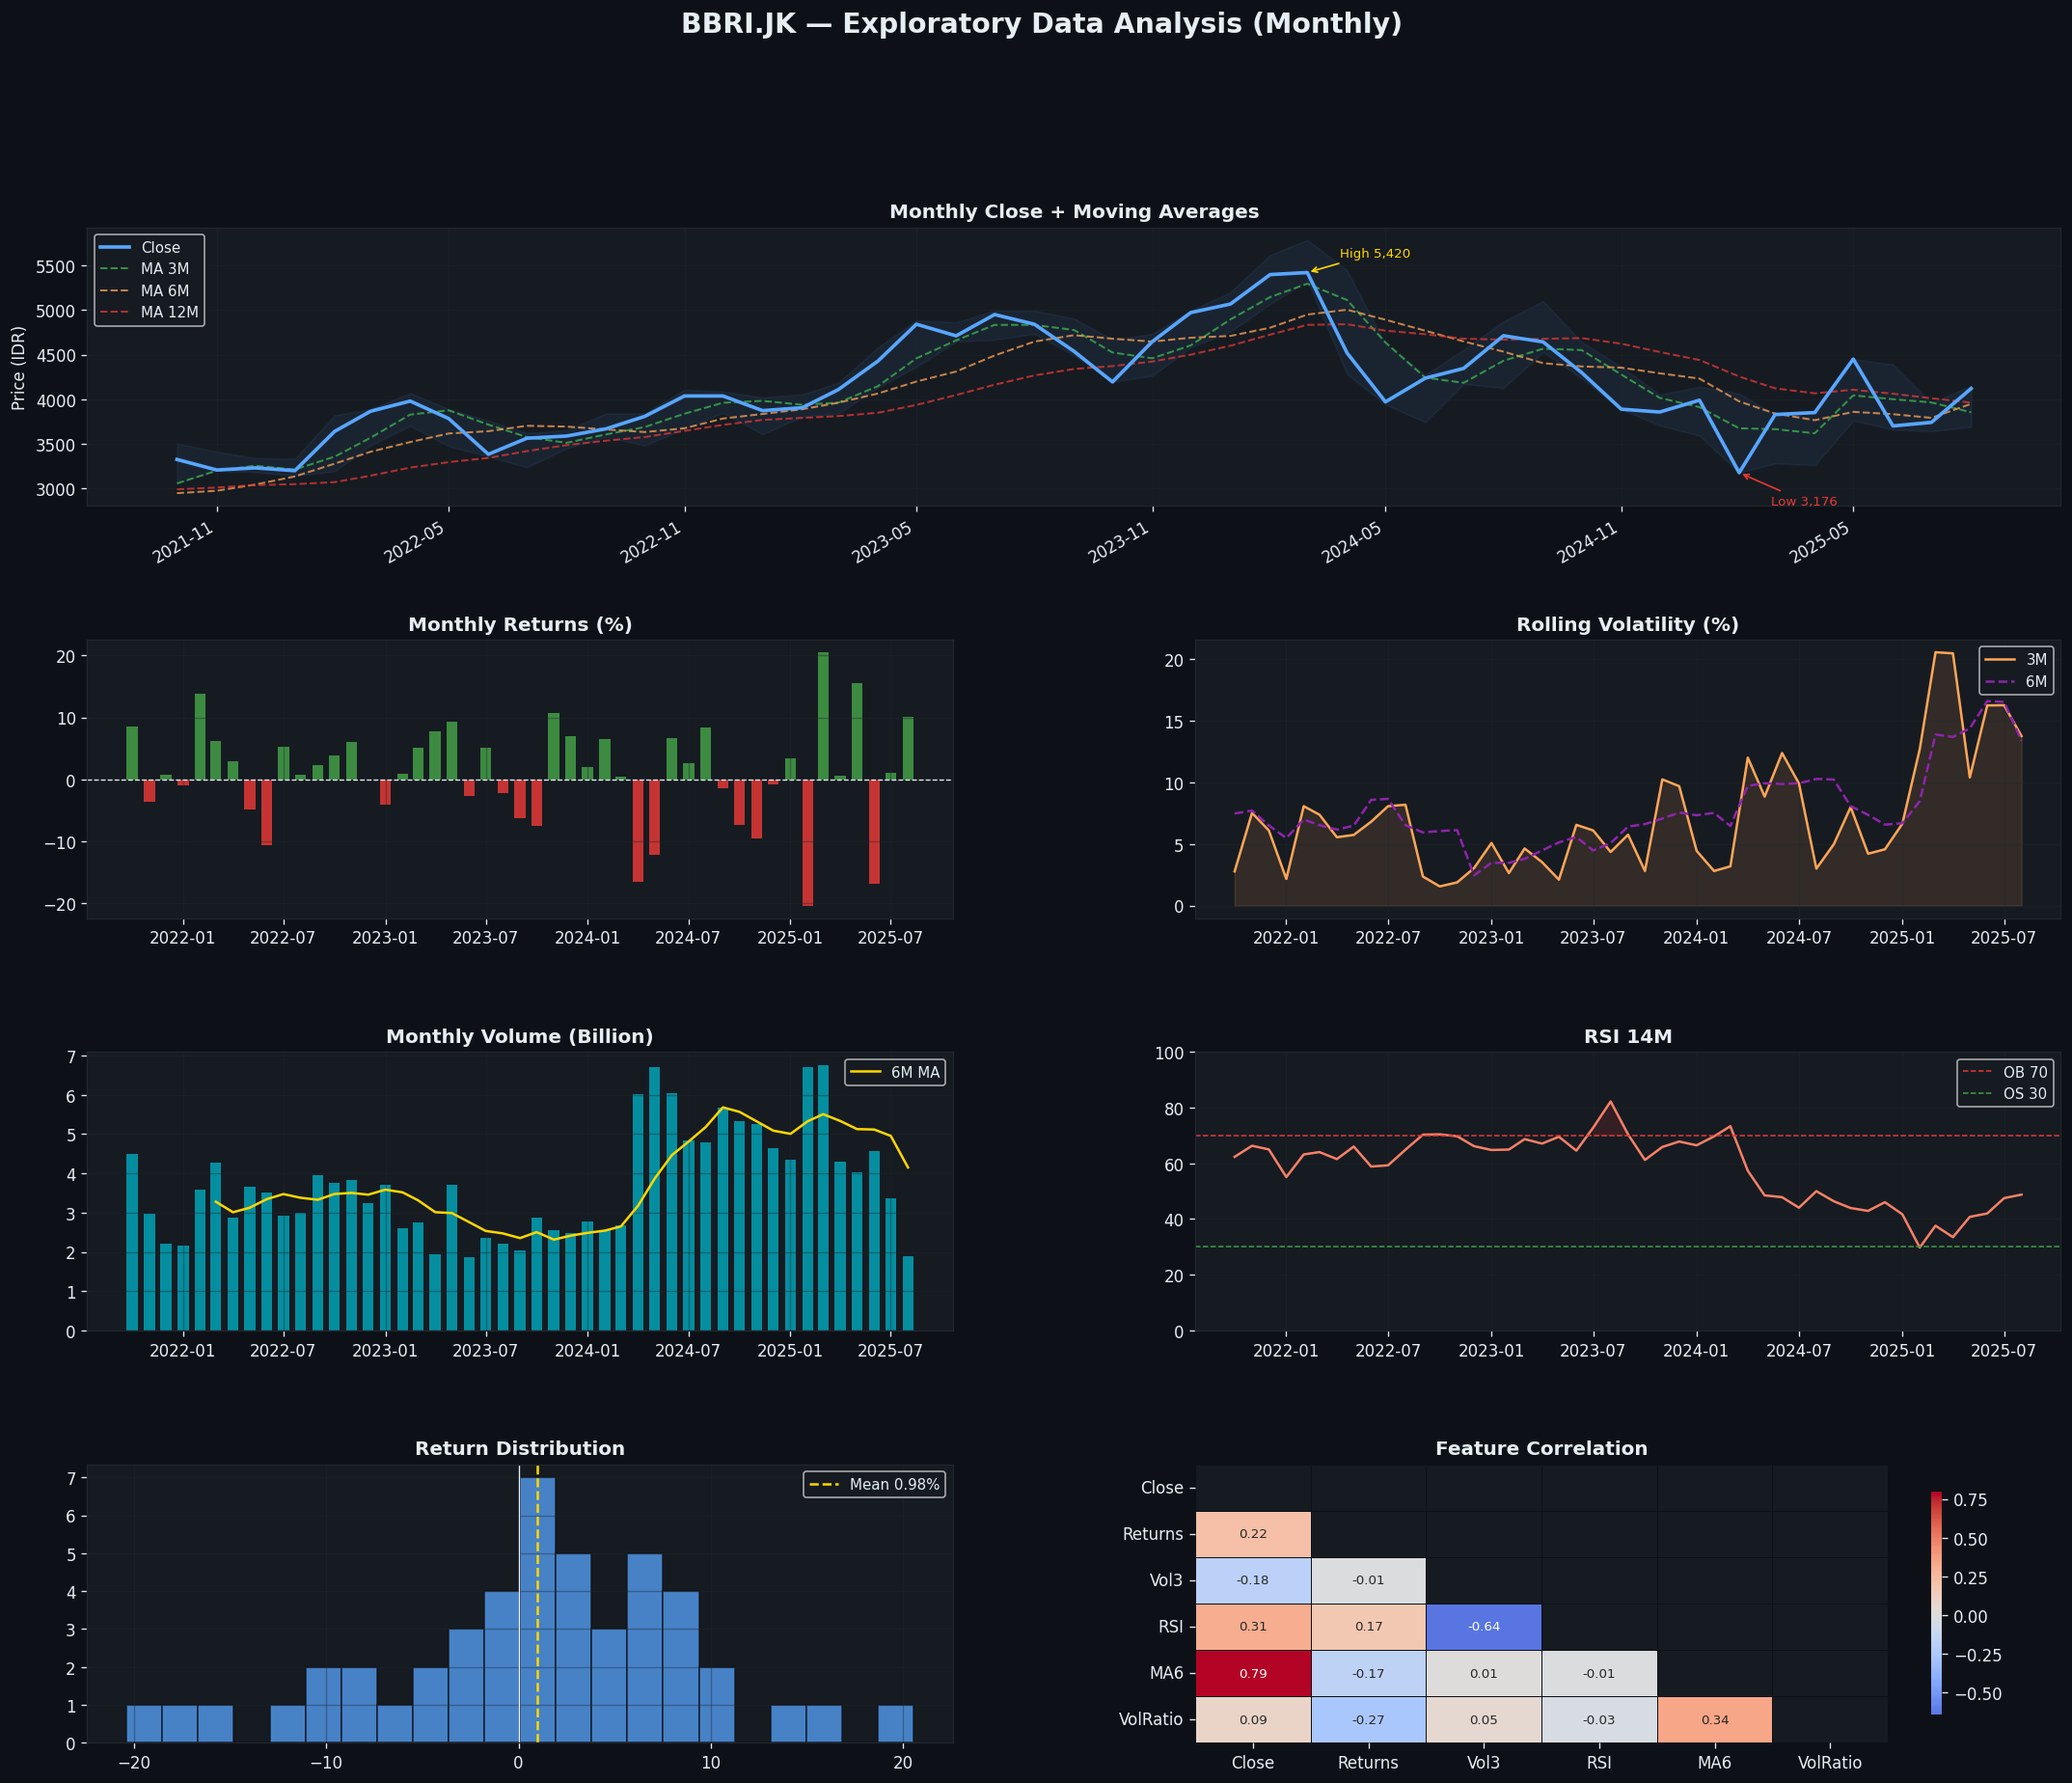

Saved: BBRI_EDA.png


In [5]:
fig = plt.figure(figsize=(22,17))
gs  = gridspec.GridSpec(4,2,figure=fig,hspace=0.48,wspace=0.28)
fig.suptitle('BBRI.JK — Exploratory Data Analysis (Monthly)',
             fontsize=17,fontweight='bold',color=C['text'],y=0.99)

ax1 = fig.add_subplot(gs[0,:])
ax1.plot(dm.index,dm['Close'],color=C['actual'],lw=2.2,label='Close',zorder=5)
ax1.plot(dm.index,dm['MA3'],  color=C['prophet'],lw=1.2,ls='--',alpha=.75,label='MA 3M')
ax1.plot(dm.index,dm['MA6'],  color=C['sarima'], lw=1.2,ls='--',alpha=.75,label='MA 6M')
ax1.plot(dm.index,dm['MA12'], color=C['red'],    lw=1.2,ls='--',alpha=.75,label='MA 12M')
ax1.fill_between(dm.index,dm['Low'],dm['High'],alpha=.07,color=C['actual'])
idx_hi = dm['Close'].idxmax(); idx_lo = dm['Close'].idxmin()
ax1.annotate(f"High {dm['Close'].max():,.0f}",xy=(idx_hi,dm['Close'].max()),
             xytext=(20,10),textcoords='offset points',color=C['ensemble'],fontsize=8,
             arrowprops=dict(arrowstyle='->',color=C['ensemble'],lw=1))
ax1.annotate(f"Low {dm['Close'].min():,.0f}",xy=(idx_lo,dm['Close'].min()),
             xytext=(20,-20),textcoords='offset points',color=C['red'],fontsize=8,
             arrowprops=dict(arrowstyle='->',color=C['red'],lw=1))
ax1.set_title('Monthly Close + Moving Averages',fontweight='bold')
ax1.set_ylabel('Price (IDR)'); ax1.legend(loc='upper left',fontsize=9)
ax1.grid(True); ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(),rotation=30,ha='right')

ax2 = fig.add_subplot(gs[1,0])
clrs = [C['green'] if r>=0 else C['red'] for r in dm['Returns']]
ax2.bar(dm.index,dm['Returns']*100,color=clrs,width=20,alpha=.85)
ax2.axhline(0,color=C['text'],lw=.8,ls='--')
ax2.set_title('Monthly Returns (%)',fontweight='bold'); ax2.grid(True)

ax3 = fig.add_subplot(gs[1,1])
ax3.plot(dm.index,dm['Vol3']*100,color=C['sarima'],lw=1.5,label='3M')
ax3.plot(dm.index,dm['Vol6']*100,color=C['purple'],lw=1.5,ls='--',label='6M')
ax3.fill_between(dm.index,dm['Vol3']*100,alpha=.12,color=C['sarima'])
ax3.set_title('Rolling Volatility (%)',fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True)

ax4 = fig.add_subplot(gs[2,0])
ax4.bar(dm.index,dm['Volume']/1e9,color=C['teal'],width=20,alpha=.8)
ax4.plot(dm.index,dm['Volume'].rolling(6).mean()/1e9,color=C['ensemble'],lw=1.5,label='6M MA')
ax4.set_title('Monthly Volume (Billion)',fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True)

ax5 = fig.add_subplot(gs[2,1])
ax5.plot(dm.index,dm['RSI'],color=C['lstm'],lw=1.5)
ax5.axhline(70,color=C['red'],  ls='--',lw=.9,label='OB 70')
ax5.axhline(30,color=C['green'],ls='--',lw=.9,label='OS 30')
ax5.fill_between(dm.index,70,dm['RSI'],where=dm['RSI']>=70,alpha=.15,color=C['red'])
ax5.fill_between(dm.index,30,dm['RSI'],where=dm['RSI']<=30,alpha=.15,color=C['green'])
ax5.set_title('RSI 14M',fontweight='bold'); ax5.set_ylim(0,100)
ax5.legend(fontsize=9); ax5.grid(True)

ax6 = fig.add_subplot(gs[3,0])
rets = dm['Returns'].dropna()*100
ax6.hist(rets,bins=22,color=C['actual'],alpha=.75,edgecolor=C['bg'],lw=.5)
ax6.axvline(rets.mean(),color=C['ensemble'],ls='--',lw=1.5,label=f'Mean {rets.mean():.2f}%')
ax6.axvline(0,color=C['text'],lw=.8)
ax6.set_title('Return Distribution',fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(True)

ax7 = fig.add_subplot(gs[3,1])
cols_c = ['Close','Returns','Vol3','RSI','MA6','VolRatio']
corr = dm[cols_c].corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,ax=ax7,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',center=0,
            annot_kws={'size':8},linewidths=.5,linecolor=C['bg'],cbar_kws={'shrink':.8})
ax7.set_title('Feature Correlation',fontweight='bold')

plt.savefig('BBRI_EDA.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show(); print('Saved: BBRI_EDA.png')


In [6]:
def adf_test(series, name):
    r = adfuller(series.dropna())
    ok = r[1] < 0.05
    print(f"{'OK' if ok else 'NO'}  {name:<25}  ADF={r[0]:+.4f}  p={r[1]:.4f}  "
          f"{'stasioner' if ok else 'TIDAK stasioner'}")

print('-'*60+' ADF TEST')
adf_test(dm['Close'],        'Close (level)')
adf_test(dm['Close'].diff(), 'Close (first diff)')
adf_test(dm['LogRet'],       'Log Returns')


------------------------------------------------------------ ADF TEST
NO  Close (level)              ADF=-2.2189  p=0.1995  TIDAK stasioner
NO  Close (first diff)         ADF=-1.1702  p=0.6863  TIDAK stasioner
NO  Log Returns                ADF=-1.4063  p=0.5792  TIDAK stasioner


In [7]:
print('Training Prophet...')

df_p = dm['Close'].reset_index().rename(columns={'Date':'ds','Close':'y'})

def make_prophet():
    m = Prophet(yearly_seasonality=True,weekly_seasonality=False,
                daily_seasonality=False,changepoint_prior_scale=0.15,
                seasonality_prior_scale=10,seasonality_mode='multiplicative',
                interval_width=0.90)
    m.add_country_holidays(country_name='ID')
    return m

mp = make_prophet()
with silent(): mp.fit(df_p)
fut_p = mp.make_future_dataframe(periods=FORECAST_MONTHS,freq='MS')
fc_p  = mp.predict(fut_p)
prophet_pred = fc_p.tail(FORECAST_MONTHS)['yhat'].values

df_p_tr = train_s.reset_index().rename(columns={'Date':'ds','Close':'y'})
mp_v = make_prophet()
with silent(): mp_v.fit(df_p_tr)
fc_pv = mp_v.predict(mp_v.make_future_dataframe(periods=VAL_MONTHS,freq='MS'))
prophet_val = fc_pv.tail(VAL_MONTHS)['yhat'].values

p_mae  = mean_absolute_error(val_s.values, prophet_val)
p_rmse = np.sqrt(mean_squared_error(val_s.values, prophet_val))
p_mape = np.mean(np.abs((val_s.values - prophet_val) / val_s.values)) * 100
print(f'Prophet  MAE={p_mae:,.0f}  RMSE={p_rmse:,.0f}  MAPE={p_mape:.2f}%')


Training Prophet...
Prophet  MAE=966  RMSE=1,204  MAPE=26.18%


In [8]:
print('Training SARIMA(2,1,2)(1,1,1,12)...')

def fit_sarima(series):
    return SARIMAX(series,order=(2,1,2),seasonal_order=(1,1,1,12),
                  enforce_stationarity=False,enforce_invertibility=False
                 ).fit(disp=False,maxiter=200)

sar_full    = fit_sarima(dm['Close'])
sar_fc      = sar_full.get_forecast(steps=FORECAST_MONTHS)
sarima_pred = sar_fc.predicted_mean.values
sarima_ci   = sar_fc.conf_int(alpha=0.10).values

sar_val     = fit_sarima(train_s)
sarima_val  = sar_val.get_forecast(steps=VAL_MONTHS).predicted_mean.values

s_mae  = mean_absolute_error(val_s.values, sarima_val)
s_rmse = np.sqrt(mean_squared_error(val_s.values, sarima_val))
s_mape = np.mean(np.abs((val_s.values - sarima_val) / val_s.values)) * 100
print(f'SARIMA   MAE={s_mae:,.0f}  RMSE={s_rmse:,.0f}  MAPE={s_mape:.2f}%')


Training SARIMA(2,1,2)(1,1,1,12)...
SARIMA   MAE=1,770  RMSE=2,139  MAPE=45.35%


In [9]:
FEAT_COLS = ['Lag1','Lag2','Lag3','MA3','MA6','MA12',
             'Returns','LogRet','Vol3','Vol6','RSI',
             'VolRatio','RangePct','Month','Quarter']

def build_features(df_slice):
    c  = df_slice['Close']
    n  = len(c)
    lag1  = float(c.iloc[-1])
    lag2  = float(c.iloc[-2]) if n >= 2 else lag1
    lag3  = float(c.iloc[-3]) if n >= 3 else lag1
    ma3   = float(c.iloc[-3:].mean())
    ma6   = float(c.iloc[-6:].mean())  if n >= 6  else lag1
    ma12  = float(c.iloc[-12:].mean()) if n >= 12 else lag1
    rets  = c.pct_change().dropna()
    ret1  = float(rets.iloc[-1])  if len(rets) > 0 else 0.0
    logr  = float(np.log(c.iloc[-1]/c.iloc[-2])) if n >= 2 else 0.0
    vol3  = float(rets.iloc[-3:].std()) if len(rets) >= 3 else 0.0
    vol6  = float(rets.iloc[-6:].std()) if len(rets) >= 6 else vol3
    dlt   = c.diff().dropna().iloc[-14:]
    g2    = dlt.clip(lower=0).mean(); l2 = (-dlt.clip(upper=0)).mean()
    rsi   = 100 - 100/(1 + g2/(l2+1e-9))
    volr  = (float(df_slice['Volume'].iloc[-1]/df_slice['Volume'].iloc[-6:].mean())
             if 'Volume' in df_slice.columns and n >= 6 else 1.0)
    rngp  = (float((df_slice['High'].iloc[-1]-df_slice['Low'].iloc[-1])/c.iloc[-1])
             if 'High' in df_slice.columns else 0.02)
    mnth  = df_slice.index[-1].month
    qtr   = df_slice.index[-1].quarter
    return [lag1,lag2,lag3,ma3,ma6,ma12,ret1,logr,vol3,vol6,float(rsi),volr,rngp,mnth,qtr]

def append_row(df_sl, pred, new_date):
    rp  = float(df_sl['RangePct'].iloc[-6:].mean()) if 'RangePct' in df_sl.columns else 0.02
    av  = float(df_sl['Volume'].iloc[-6:].mean())   if 'Volume'   in df_sl.columns else 0
    rng = pred * rp
    row = {'Open':float(df_sl['Close'].iloc[-1]),'High':pred+rng/2,
           'Low':pred-rng/2,'Close':pred,'Volume':av}
    out = pd.concat([df_sl, pd.DataFrame([row],index=[new_date])])
    c   = out['Close']
    out['Returns']  = c.pct_change()
    out['LogRet']   = np.log(c/c.shift(1))
    out['MA3']      = c.rolling(3).mean()
    out['MA6']      = c.rolling(6).mean()
    out['MA12']     = c.rolling(12).mean()
    out['Vol3']     = out['Returns'].rolling(3).std()
    out['Vol6']     = out['Returns'].rolling(6).std()
    out['RangePct'] = (out['High']-out['Low'])/c
    out['VolRatio'] = out['Volume']/out['Volume'].rolling(6).mean()
    out['Lag1']     = c.shift(1)
    out['Lag2']     = c.shift(2)
    out['Lag3']     = c.shift(3)
    out['Month']    = out.index.month
    out['Quarter']  = out.index.quarter
    d2=c.diff(); g3=d2.clip(lower=0).rolling(14).mean()
    l3=(-d2.clip(upper=0)).rolling(14).mean()
    out['RSI'] = 100-100/(1+g3/(l3+1e-9))
    return out

print('XGBoost helpers ready.')


XGBoost helpers ready.


In [10]:
print('Training XGBoost...')

df_xgb = dm[FEAT_COLS+['Close']].dropna()
X_all  = df_xgb[FEAT_COLS].values
y_all  = df_xgb['Close'].values
split  = len(X_all) - VAL_MONTHS
X_tr,X_v = X_all[:split],X_all[split:]
y_tr,y_v = y_all[:split],y_all[split:]

sc_x  = StandardScaler()
Xts   = sc_x.fit_transform(X_tr)
Xvs   = sc_x.transform(X_v)

xgb_m = xgb.XGBRegressor(
    n_estimators=600,learning_rate=0.03,max_depth=4,
    subsample=0.8,colsample_bytree=0.8,
    reg_alpha=0.1,reg_lambda=1.0,
    early_stopping_rounds=40,eval_metric='rmse',random_state=42)
xgb_m.fit(Xts,y_tr,eval_set=[(Xvs,y_v)],verbose=False)

xgb_val  = xgb_m.predict(Xvs)
x_mae  = mean_absolute_error(y_v,xgb_val)
x_rmse = np.sqrt(mean_squared_error(y_v,xgb_val))
x_mape = np.mean(np.abs((y_v-xgb_val)/y_v))*100

dm_iter    = dm.copy()
xgb_future = []
for step in range(FORECAST_MONTHS):
    fvec   = build_features(dm_iter)
    fvec_s = sc_x.transform([fvec])
    pred   = float(xgb_m.predict(fvec_s)[0])
    xgb_future.append(pred)
    new_date = dm_iter.index[-1] + relativedelta(months=1)
    dm_iter  = append_row(dm_iter, pred, new_date)
    print(f'  Step {step+1:02d}: {new_date.strftime("%Y-%m")} -> {pred:,.0f}')

xgb_pred = np.array(xgb_future)
print(f'XGBoost  MAE={x_mae:,.0f}  RMSE={x_rmse:,.0f}  MAPE={x_mape:.2f}%')


Training XGBoost...
  Step 01: 2025-09 -> 4,084
  Step 02: 2025-10 -> 3,971
  Step 03: 2025-11 -> 3,955
  Step 04: 2025-12 -> 3,916
  Step 05: 2026-01 -> 3,967
  Step 06: 2026-02 -> 3,983
  Step 07: 2026-03 -> 3,990
  Step 08: 2026-04 -> 4,003
  Step 09: 2026-05 -> 4,024
  Step 10: 2026-06 -> 4,012
  Step 11: 2026-07 -> 4,011
  Step 12: 2026-08 -> 4,011
XGBoost  MAE=218  RMSE=289  MAPE=5.79%


In [11]:
print('Training LSTM...')

LOOK_BACK = 12
sc_lstm   = MinMaxScaler(feature_range=(0,1))
cs        = sc_lstm.fit_transform(dm['Close'].values.reshape(-1,1))

def make_seq(data, lb):
    X, y = [], []
    for i in range(len(data)-lb):
        X.append(data[i:i+lb,0])
        y.append(data[i+lb,0])
    return np.array(X), np.array(y)

Xs,ys = make_seq(cs,LOOK_BACK)
Xs    = Xs.reshape(*Xs.shape,1)
sp    = len(Xs) - VAL_MONTHS
Xt,Xv2 = Xs[:sp],Xs[sp:]
yt,yv2 = ys[:sp],ys[sp:]

lstm_m = Sequential([
    LSTM(128,return_sequences=True,input_shape=(LOOK_BACK,1)),
    Dropout(0.20), BatchNormalization(),
    LSTM(64,return_sequences=True),
    Dropout(0.20), BatchNormalization(),
    LSTM(32),
    Dropout(0.10),
    Dense(16,activation='relu'),
    Dense(1),
])
lstm_m.compile(optimizer=Adam(1e-3),loss='huber',metrics=['mae'])

hist_lstm = lstm_m.fit(
    Xt,yt,epochs=250,batch_size=8,
    validation_data=(Xv2,yv2),
    callbacks=[
        EarlyStopping(patience=35,restore_best_weights=True,verbose=0),
        ReduceLROnPlateau(patience=15,factor=0.5,min_lr=1e-5,verbose=0),
    ], verbose=0)

lstm_val_s  = lstm_m.predict(Xv2,verbose=0)
lstm_val    = sc_lstm.inverse_transform(lstm_val_s).flatten()
val_actual  = sc_lstm.inverse_transform(yv2.reshape(-1,1)).flatten()
l_mae  = mean_absolute_error(val_actual,lstm_val)
l_rmse = np.sqrt(mean_squared_error(val_actual,lstm_val))
l_mape = np.mean(np.abs((val_actual-lstm_val)/val_actual))*100

seed        = cs[-LOOK_BACK:].reshape(1,LOOK_BACK,1)
lstm_future = []
for _ in range(FORECAST_MONTHS):
    p = float(lstm_m.predict(seed,verbose=0)[0,0])
    lstm_future.append(p)
    seed = np.append(seed[0,1:,0],p).reshape(1,LOOK_BACK,1)
lstm_pred = sc_lstm.inverse_transform(np.array(lstm_future).reshape(-1,1)).flatten()

print(f'LSTM epochs={len(hist_lstm.epoch)} params={lstm_m.count_params():,}')
print(f'LSTM     MAE={l_mae:,.0f}  RMSE={l_rmse:,.0f}  MAPE={l_mape:.2f}%')


Training LSTM...
LSTM epochs=75 params=129,697
LSTM     MAE=265  RMSE=360  MAPE=6.71%


In [12]:
mapes   = np.array([p_mape,s_mape,x_mape,l_mape])
inv_m   = 1.0/(mapes+1e-9)
weights = inv_m/inv_m.sum()
names   = ['Prophet','SARIMA','XGBoost','LSTM']
maes_v  = [p_mae,s_mae,x_mae,l_mae]
rmses_v = [p_rmse,s_rmse,x_rmse,l_rmse]

print('='*62)
print('  MODEL COMPARISON — Validation last 12 months')
print('='*62)
print(f"  {'Model':<10} {'MAE':>9} {'RMSE':>9} {'MAPE':>7}  {'Weight':>7}")
for i,nm in enumerate(names):
    print(f'  {nm:<10} {maes_v[i]:>9,.0f} {rmses_v[i]:>9,.0f} '
          f'{mapes[i]:>6.2f}%  {weights[i]:>7.3f}')
print('='*62)

ensemble_pred = (weights[0]*prophet_pred + weights[1]*sarima_pred +
                 weights[2]*xgb_pred     + weights[3]*lstm_pred)

stack    = np.vstack([prophet_pred,sarima_pred,xgb_pred,lstm_pred])
ens_std  = stack.std(axis=0)
lo90     = ensemble_pred - 1.645*ens_std
hi90     = ensemble_pred + 1.645*ens_std
lo68     = ensemble_pred - 1.000*ens_std
hi68     = ensemble_pred + 1.000*ens_std

df_fc = pd.DataFrame({
    'Prophet':prophet_pred,'SARIMA':sarima_pred,
    'XGBoost':xgb_pred,'LSTM':lstm_pred,
    'Ensemble':ensemble_pred,
    'Lo68':lo68,'Hi68':hi68,'Lo90':lo90,'Hi90':hi90,
}, index=future_dates)

print('\n  FORECAST TABLE')
print(f"  {'Month':<10} {'Ensemble':>10} {'Lo 90%':>10} {'Hi 90%':>10} {'Change%':>8}")
for dt,row in df_fc.iterrows():
    pct = (row['Ensemble']/last_price-1)*100
    arr = chr(9650) if pct>=0 else chr(9660)
    print(f"  {dt.strftime('%Y-%m'):<10} {row['Ensemble']:>10,.0f} "
          f"{row['Lo90']:>10,.0f} {row['Hi90']:>10,.0f}  {arr}{abs(pct):>5.1f}%")


  MODEL COMPARISON — Validation last 12 months
  Model            MAE      RMSE    MAPE   Weight
  Prophet          966     1,204  26.18%    0.100
  SARIMA         1,770     2,139  45.35%    0.058
  XGBoost          218       289   5.79%    0.452
  LSTM             265       360   6.71%    0.390

  FORECAST TABLE
  Month        Ensemble     Lo 90%     Hi 90%  Change%
  2025-09         3,950      3,787      4,114  ▼  4.1%
  2025-10         3,857      3,581      4,133  ▼  6.4%
  2025-11         3,862      3,576      4,147  ▼  6.3%
  2025-12         3,859      3,477      4,242  ▼  6.3%
  2026-01         3,886      3,470      4,302  ▼  5.7%
  2026-02         3,893      3,022      4,764  ▼  5.5%
  2026-03         3,926      3,128      4,724  ▼  4.7%
  2026-04         3,872      3,598      4,147  ▼  6.0%
  2026-05         3,841      3,166      4,515  ▼  6.8%
  2026-06         3,826      3,288      4,364  ▼  7.1%
  2026-07         3,833      3,305      4,360  ▼  7.0%
  2026-08         3,857  

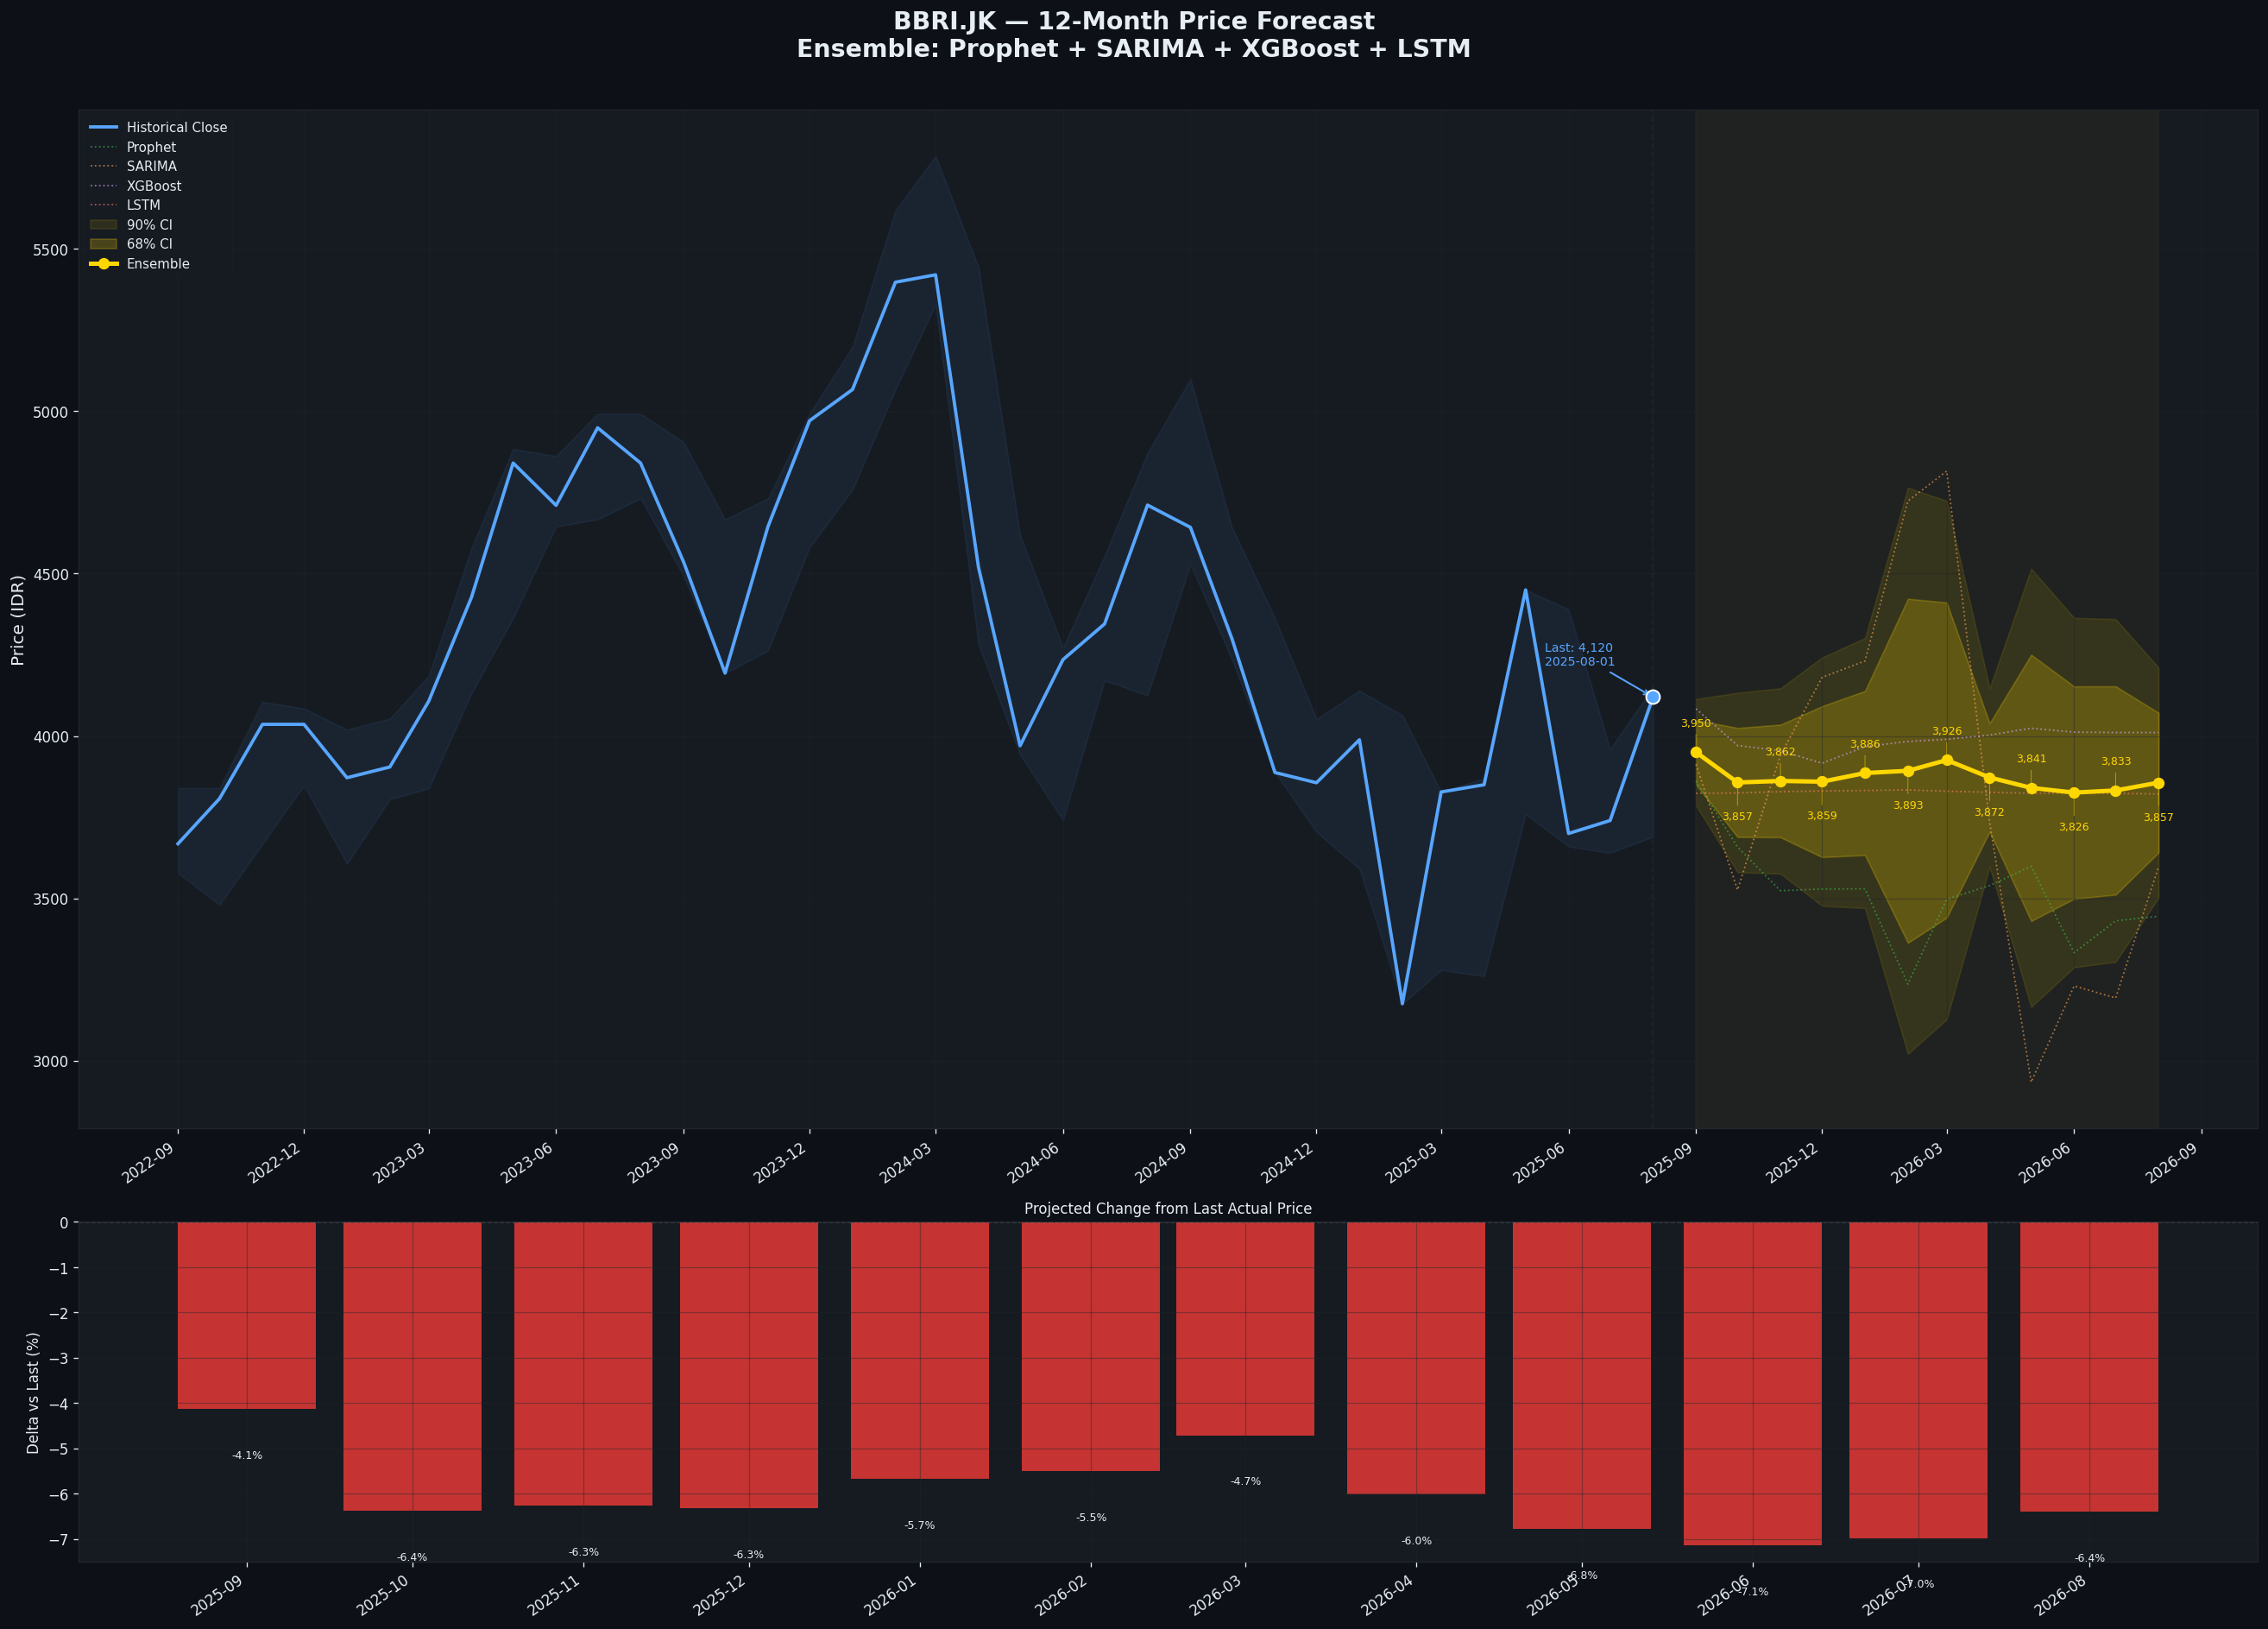

Saved: BBRI_Forecast_Main.png


In [13]:
HIST = 36
hist_plot = dm['Close'].iloc[-HIST:]

fig, axes = plt.subplots(2,1,figsize=(22,16),
                          gridspec_kw={'height_ratios':[3,1]})
fig.suptitle(
    'BBRI.JK — 12-Month Price Forecast\n'
    'Ensemble: Prophet + SARIMA + XGBoost + LSTM',
    fontsize=17,fontweight='bold',color=C['text'],y=0.98)

ax = axes[0]
ax.plot(hist_plot.index,hist_plot.values,color=C['actual'],lw=2.3,
        label='Historical Close',zorder=5)
ax.fill_between(hist_plot.index,
                dm['Low'].iloc[-HIST:],dm['High'].iloc[-HIST:],
                alpha=.07,color=C['actual'])
ax.axvline(last_date,color=C['grid'],ls='--',lw=1.2,alpha=.8)
ax.axvspan(df_fc.index[0],df_fc.index[-1],alpha=.04,color=C['ensemble'])

for nm,col in [('Prophet',C['prophet']),('SARIMA',C['sarima']),
               ('XGBoost',C['xgboost']),('LSTM',C['lstm'])]:
    ax.plot(df_fc.index,df_fc[nm],color=col,lw=1.1,ls=':',alpha=.6,label=nm)

ax.fill_between(df_fc.index,df_fc['Lo90'],df_fc['Hi90'],
                alpha=.10,color=C['ensemble'],label='90% CI')
ax.fill_between(df_fc.index,df_fc['Lo68'],df_fc['Hi68'],
                alpha=.22,color=C['ensemble'],label='68% CI')
ax.plot(df_fc.index,df_fc['Ensemble'],
        color=C['ensemble'],lw=3.0,marker='o',ms=7,
        label='Ensemble',zorder=10)

for i,(dt,row) in enumerate(df_fc.iterrows()):
    v  = row['Ensemble']
    dy = 18 if i%2==0 else -26
    ax.annotate(f'{v:,.0f}',xy=(dt,v),xytext=(0,dy),
                textcoords='offset points',ha='center',
                fontsize=7.5,color=C['ensemble'],
                arrowprops=dict(arrowstyle='-',color=C['ensemble'],lw=.6,alpha=.5))

ax.scatter([last_date],[last_price],s=90,color=C['actual'],
           zorder=15,edgecolors='white',lw=1.2)
ax.annotate(f'Last: {last_price:,.0f}\n{last_date.date()}',
            xy=(last_date,last_price),xytext=(-75,22),
            textcoords='offset points',color=C['actual'],fontsize=8.5,
            arrowprops=dict(arrowstyle='->',color=C['actual'],lw=1.2))

ax.set_ylabel('Price (IDR)',fontsize=12)
ax.legend(loc='upper left',fontsize=9,framealpha=.3,
          facecolor=C['surface'],edgecolor=C['grid'])
ax.grid(True); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=35,ha='right')

ax2 = axes[1]
pcts = (df_fc['Ensemble']/last_price-1)*100
bar_c = [C['green'] if p>=0 else C['red'] for p in pcts]
ax2.bar(df_fc.index,pcts,color=bar_c,width=25,alpha=.85)
ax2.axhline(0,color=C['text'],lw=.8,ls='--')
for dt,val in zip(df_fc.index,pcts):
    ax2.text(dt,val+(.25 if val>=0 else -.9),f'{val:+.1f}%',
             ha='center',va='bottom' if val>=0 else 'top',
             fontsize=7.5,color=C['text'])
ax2.set_ylabel('Delta vs Last (%)',fontsize=10)
ax2.set_title('Projected Change from Last Actual Price',fontsize=10)
ax2.grid(True); ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=35,ha='right')

plt.tight_layout(rect=[0,0,1,.97])
plt.savefig('BBRI_Forecast_Main.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show(); print('Saved: BBRI_Forecast_Main.png')


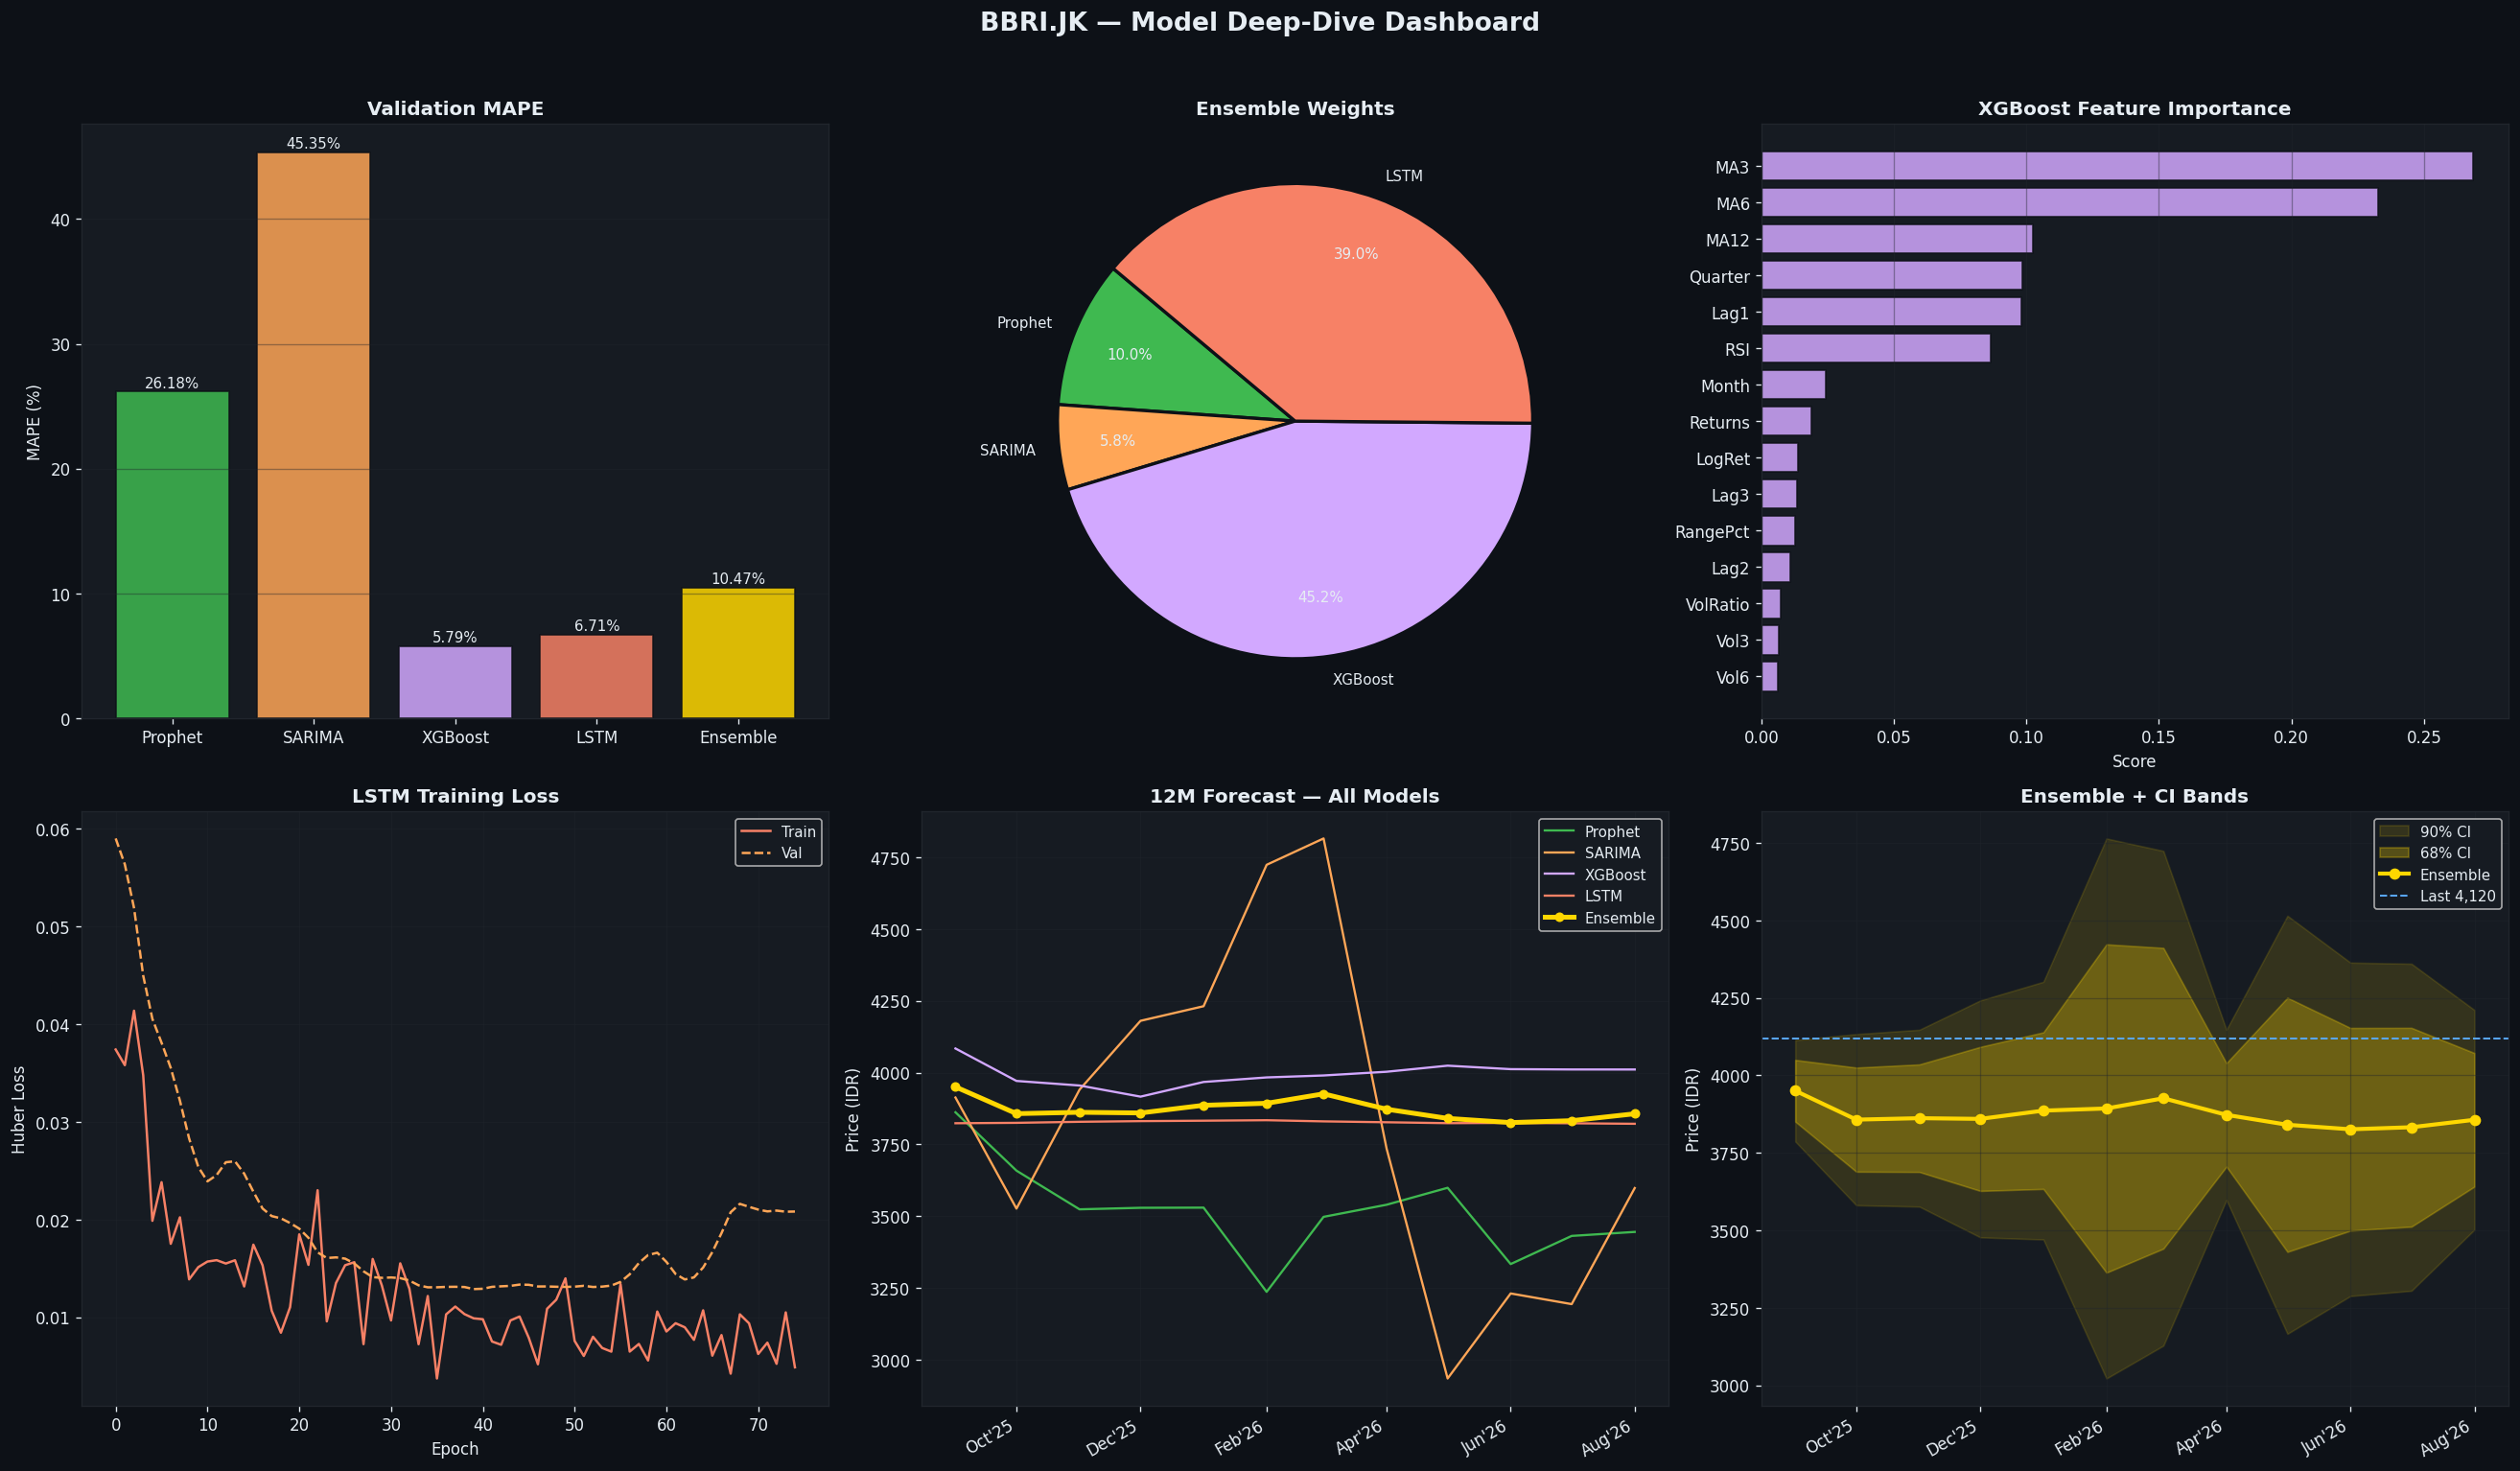

Saved: BBRI_Model_Dashboard.png


In [14]:
fig, axes = plt.subplots(2,3,figsize=(22,13))
fig.suptitle('BBRI.JK — Model Deep-Dive Dashboard',
             fontsize=16,fontweight='bold',color=C['text'])
axes = axes.flatten()

ax = axes[0]
mape_all  = list(mapes)+[float(np.average(mapes,weights=weights))]
names_all = names+['Ensemble']
bcols = [C['prophet'],C['sarima'],C['xgboost'],C['lstm'],C['ensemble']]
bars  = ax.bar(names_all,mape_all,color=bcols,alpha=.85,edgecolor=C['bg'])
for b,v in zip(bars,mape_all):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,
            f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
ax.set_title('Validation MAPE',fontweight='bold')
ax.set_ylabel('MAPE (%)'); ax.grid(True,axis='y')

ax = axes[1]
wedges,texts,autos = ax.pie(
    weights,labels=names,autopct='%1.1f%%',
    colors=[C['prophet'],C['sarima'],C['xgboost'],C['lstm']],
    startangle=140,pctdistance=.75,
    wedgeprops={'edgecolor':C['bg'],'linewidth':2})
for t in texts+autos: t.set_color(C['text']); t.set_fontsize(9)
ax.set_title('Ensemble Weights',fontweight='bold')

ax = axes[2]
fi = pd.Series(xgb_m.feature_importances_,index=FEAT_COLS).sort_values()
ax.barh(fi.index,fi.values,color=C['xgboost'],alpha=.85,edgecolor=C['bg'])
ax.set_title('XGBoost Feature Importance',fontweight='bold')
ax.set_xlabel('Score'); ax.grid(True,axis='x')

ax = axes[3]
ax.plot(hist_lstm.history['loss'],    color=C['lstm'],  lw=1.5,label='Train')
ax.plot(hist_lstm.history['val_loss'],color=C['sarima'],lw=1.5,ls='--',label='Val')
ax.set_title('LSTM Training Loss',fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.legend(fontsize=9); ax.grid(True)

ax = axes[4]
for nm,col in [('Prophet',C['prophet']),('SARIMA',C['sarima']),
               ('XGBoost',C['xgboost']),('LSTM',C['lstm']),
               ('Ensemble',C['ensemble'])]:
    lw = 3.0 if nm=='Ensemble' else 1.4
    ax.plot(df_fc.index,df_fc[nm],color=col,lw=lw,
            marker=('o' if nm=='Ensemble' else None),ms=5,label=nm,
            zorder=(10 if nm=='Ensemble' else 5))
ax.set_title('12M Forecast — All Models',fontweight='bold')
ax.set_ylabel('Price (IDR)'); ax.legend(fontsize=9); ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')

ax = axes[5]
ax.fill_between(df_fc.index,df_fc['Lo90'],df_fc['Hi90'],
                alpha=.13,color=C['ensemble'],label='90% CI')
ax.fill_between(df_fc.index,df_fc['Lo68'],df_fc['Hi68'],
                alpha=.28,color=C['ensemble'],label='68% CI')
ax.plot(df_fc.index,df_fc['Ensemble'],
        color=C['ensemble'],lw=2.5,marker='o',ms=6,label='Ensemble',zorder=10)
ax.axhline(last_price,color=C['actual'],ls='--',lw=1.2,
           label=f'Last {last_price:,.0f}')
ax.set_title('Ensemble + CI Bands',fontweight='bold')
ax.set_ylabel('Price (IDR)'); ax.legend(fontsize=9); ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')

plt.tight_layout(rect=[0,0,1,.96])
plt.savefig('BBRI_Model_Dashboard.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show(); print('Saved: BBRI_Model_Dashboard.png')


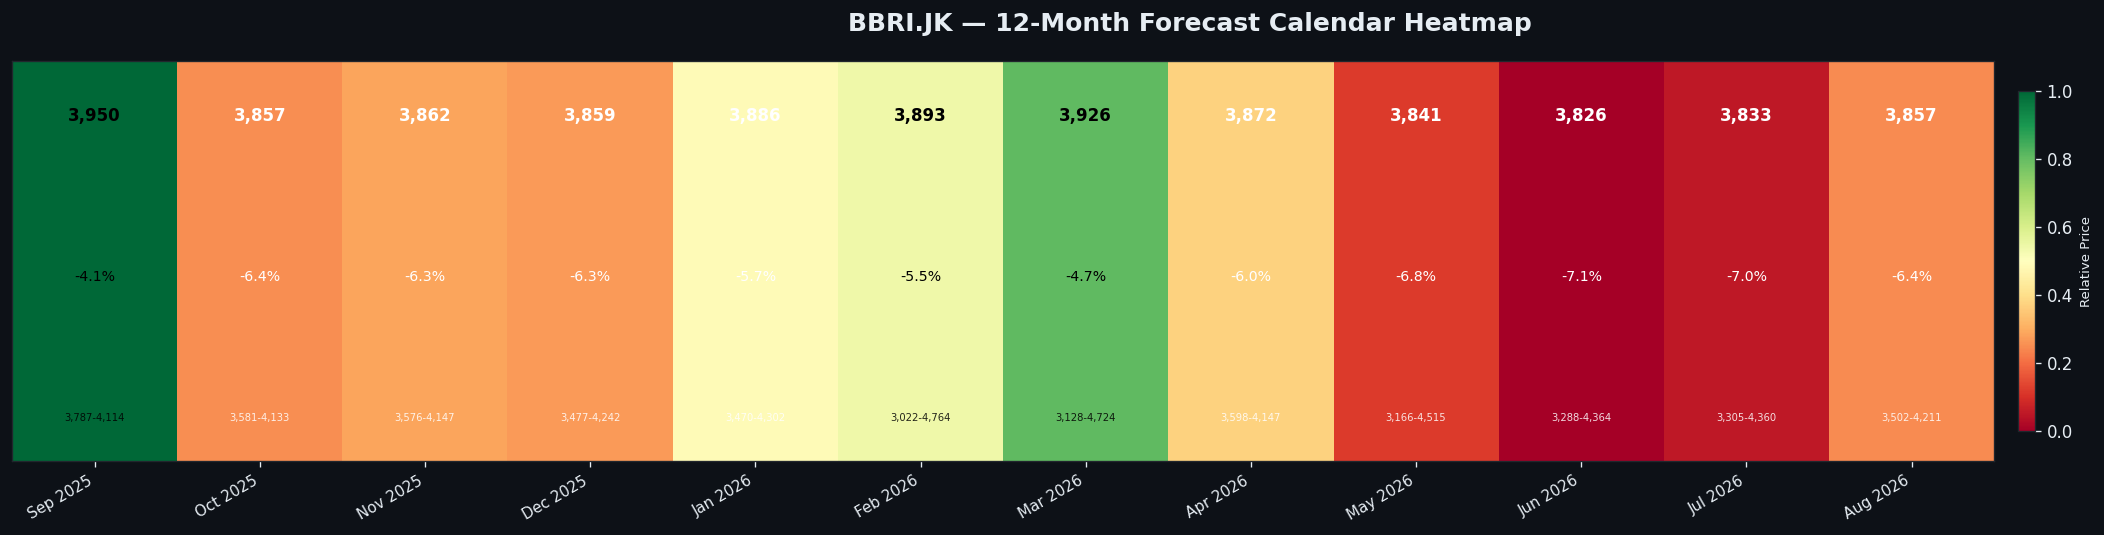

Saved: BBRI_Forecast_Heatmap.png


In [15]:
fig,ax = plt.subplots(figsize=(20,4.5))
fig.suptitle('BBRI.JK — 12-Month Forecast Calendar Heatmap',
             fontsize=15,fontweight='bold',color=C['text'])
fig.patch.set_facecolor(C['bg']); ax.set_facecolor(C['surface'])

mlbl  = [d.strftime('%b %Y') for d in df_fc.index]
ens   = df_fc['Ensemble'].values
lo90v = df_fc['Lo90'].values
hi90v = df_fc['Hi90'].values
pcts  = (ens/last_price-1)*100
norm  = (ens-ens.min())/(ens.max()-ens.min()+1e-9)

im = ax.imshow(norm.reshape(1,-1),aspect='auto',cmap='RdYlGn',vmin=0,vmax=1)
ax.set_xticks(range(len(mlbl)))
ax.set_xticklabels(mlbl,rotation=30,ha='right',fontsize=9)
ax.set_yticks([])

for i,(e,lo,hi,pct,n) in enumerate(zip(ens,lo90v,hi90v,pcts,norm)):
    fc = 'black' if n>.5 else 'white'
    ax.text(i,-.35,f'{e:,.0f}',ha='center',fontsize=10,fontweight='bold',color=fc)
    ax.text(i, .05,f'{pct:+.1f}%',ha='center',fontsize=8.5,color=fc)
    ax.text(i, .40,f'{lo:,.0f}-{hi:,.0f}',ha='center',fontsize=6,color=fc,alpha=.85)

cbar = plt.colorbar(im,ax=ax,orientation='vertical',shrink=.85,pad=.01)
cbar.set_label('Relative Price',color=C['text'],fontsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(),color=C['text'])

plt.tight_layout()
plt.savefig('BBRI_Forecast_Heatmap.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show(); print('Saved: BBRI_Forecast_Heatmap.png')


In [16]:
fig_i = make_subplots(rows=2,cols=1,shared_xaxes=True,
                      row_heights=[.75,.25],
                      subplot_titles=['BBRI.JK 12-Month Forecast','Delta% vs Last'],
                      vertical_spacing=.06)

hist36 = dm['Close'].iloc[-36:]
fig_i.add_trace(go.Scatter(
    x=hist36.index,y=hist36.values,name='Historical',
    line=dict(color='#58A6FF',width=2),
    hovertemplate='%{x|%Y-%m}<br>%{y:,.0f} IDR<extra></extra>'),row=1,col=1)

x_band = list(df_fc.index)+list(df_fc.index[::-1])
fig_i.add_trace(go.Scatter(
    x=x_band,y=list(df_fc['Hi90'])+list(df_fc['Lo90'][::-1]),
    fill='toself',fillcolor='rgba(255,215,0,0.08)',
    line=dict(color='rgba(0,0,0,0)'),name='90% CI',hoverinfo='skip'),row=1,col=1)
fig_i.add_trace(go.Scatter(
    x=x_band,y=list(df_fc['Hi68'])+list(df_fc['Lo68'][::-1]),
    fill='toself',fillcolor='rgba(255,215,0,0.18)',
    line=dict(color='rgba(0,0,0,0)'),name='68% CI',hoverinfo='skip'),row=1,col=1)

for nm,col in [('Prophet','#3FB950'),('SARIMA','#FFA657'),
               ('XGBoost','#D2A8FF'),('LSTM','#F78166')]:
    fig_i.add_trace(go.Scatter(
        x=df_fc.index,y=df_fc[nm],name=nm,
        line=dict(color=col,width=1.2,dash='dot'),opacity=.6,
        hovertemplate=f'{nm}: %{{y:,.0f}}<extra></extra>'),row=1,col=1)

fig_i.add_trace(go.Scatter(
    x=df_fc.index,y=df_fc['Ensemble'],name='Ensemble',
    line=dict(color='#FFD700',width=3),mode='lines+markers',
    marker=dict(size=8,color='#FFD700',line=dict(color='white',width=1.5)),
    hovertemplate='%{x|%Y-%m}<br><b>%{y:,.0f} IDR</b><extra></extra>'),row=1,col=1)

pcts_i  = (df_fc['Ensemble']/last_price-1)*100
bar_ci  = ['#3FB950' if p>=0 else '#E53935' for p in pcts_i]
fig_i.add_trace(go.Bar(
    x=df_fc.index,y=pcts_i,name='Delta%',
    marker_color=bar_ci,
    hovertemplate='%{x|%Y-%m}<br>%{y:.2f}%<extra></extra>'),row=2,col=1)

fig_i.update_layout(
    template='plotly_dark',paper_bgcolor='#0D1117',plot_bgcolor='#161B22',
    height=750,hovermode='x unified',
    legend=dict(bgcolor='rgba(22,27,34,.8)',bordercolor='#21262D',
                borderwidth=1,font=dict(size=11)),
    title=dict(text='<b>BBRI.JK — 12-Month Ensemble Price Forecast</b>',
               font=dict(size=16),x=.5,xanchor='center'))
fig_i.update_xaxes(gridcolor='#21262D')
fig_i.update_yaxes(gridcolor='#21262D')
fig_i.show()
fig_i.write_html('BBRI_Interactive_Forecast.html')
print('Saved: BBRI_Interactive_Forecast.html')


Saved: BBRI_Interactive_Forecast.html


In [17]:
target_12m = df_fc['Ensemble'].iloc[-1]
total_pct  = (target_12m/last_price-1)*100

print('='*70)
print('       BBRI.JK  12-MONTH FORECAST REPORT')
print(f'       Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('='*70)
print(f'  Last Price       : IDR {last_price:>10,.0f}  ({last_date.date()})')
print(f'  12M Target       : IDR {target_12m:>10,.0f}')
print(f'  Expected Return  : {total_pct:+.2f}%')
print(f'  90% CI (12M end) : IDR {df_fc["Lo90"].iloc[-1]:,.0f} - {df_fc["Hi90"].iloc[-1]:,.0f}')
print()
print(f"  {'Month':<10} {'Ensemble':>10} {'Lo 90%':>10} {'Hi 90%':>10}  {'Change%':>8}")
print('  '+'-'*56)
for dt,row in df_fc.iterrows():
    pct = (row['Ensemble']/last_price-1)*100
    arr = chr(9650) if pct>=0 else chr(9660)
    print(f"  {dt.strftime('%Y-%m'):<10} {row['Ensemble']:>10,.0f} "
          f"{row['Lo90']:>10,.0f} {row['Hi90']:>10,.0f}  {arr}{abs(pct):>5.1f}%")
print('='*70)
print()

out = df_fc[['Prophet','SARIMA','XGBoost','LSTM','Ensemble',
             'Lo68','Hi68','Lo90','Hi90']].round(0).copy()
out.index = out.index.strftime('%Y-%m')
out.to_csv('BBRI_Forecast_Results.csv')
print('Exported: BBRI_Forecast_Results.csv')
print()
print('DISCLAIMER: For educational/research purposes only.')
print('Consult a licensed financial advisor before investing.')


       BBRI.JK  12-MONTH FORECAST REPORT
       Generated: 2026-05-20 10:52
  Last Price       : IDR      4,120  (2025-08-01)
  12M Target       : IDR      3,857
  Expected Return  : -6.39%
  90% CI (12M end) : IDR 3,502 - 4,211

  Month        Ensemble     Lo 90%     Hi 90%   Change%
  --------------------------------------------------------
  2025-09         3,950      3,787      4,114  ▼  4.1%
  2025-10         3,857      3,581      4,133  ▼  6.4%
  2025-11         3,862      3,576      4,147  ▼  6.3%
  2025-12         3,859      3,477      4,242  ▼  6.3%
  2026-01         3,886      3,470      4,302  ▼  5.7%
  2026-02         3,893      3,022      4,764  ▼  5.5%
  2026-03         3,926      3,128      4,724  ▼  4.7%
  2026-04         3,872      3,598      4,147  ▼  6.0%
  2026-05         3,841      3,166      4,515  ▼  6.8%
  2026-06         3,826      3,288      4,364  ▼  7.1%
  2026-07         3,833      3,305      4,360  ▼  7.0%
  2026-08         3,857      3,502      4,211  ▼  

In [19]:
# ════════════════════════════════════════════════════════
#  ACCURACY EVALUATION — BBRI.JK Forecast
#  Jalankan setelah sel Ensemble (sel 12) selesai
# ════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Helper metrics ────────────────────────────────────
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    return np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100

def mase(y_true, y_pred, y_train):
    naive_err = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive_err

def directional_accuracy(y_true, y_pred):
    """Berapa % prediksi arah naik/turun yang benar."""
    true_dir = np.diff(y_true) > 0
    pred_dir = np.diff(y_pred) > 0
    return np.mean(true_dir == pred_dir) * 100

# ── Data aktual validation ─────────────────────────────
# val_s  = actual (sudah ada dari sel sebelumnya)
# VAL_MONTHS sudah didefinisikan = 12

y_true = val_s.values  # 12 bulan actual

# Prediksi masing-masing model pada periode validasi
y_models = {
    'Prophet': prophet_val,
    'SARIMA':  sarima_val,
    'XGBoost': xgb_val,      # dari sc_x.predict(Xvs)
    'LSTM':    lstm_val,
}

# Ensemble validation (weighted)
y_ens_val = (weights[0]*prophet_val +
             weights[1]*sarima_val  +
             weights[2]*xgb_val     +
             weights[3]*lstm_val)

y_models['Ensemble'] = y_ens_val

# ── Hitung semua metrik ────────────────────────────────
rows = []
for name, y_pred in y_models.items():
    mae_v   = mean_absolute_error(y_true, y_pred)
    rmse_v  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_v  = mape(y_true, y_pred)
    smape_v = smape(y_true, y_pred)
    r2_v    = r2_score(y_true, y_pred)
    mase_v  = mase(y_true, y_pred, train_s.values)
    da_v    = directional_accuracy(y_true, y_pred)
    rows.append({
        'Model':   name,
        'MAE':     mae_v,
        'RMSE':    rmse_v,
        'MAPE (%)':mape_v,
        'sMAPE (%)':smape_v,
        'R²':      r2_v,
        'MASE':    mase_v,
        'Dir.Acc (%)': da_v,
    })

df_metrics = pd.DataFrame(rows).set_index('Model')

print('═'*75)
print('  ACCURACY REPORT — Validation Period (last 12 months)')
print('═'*75)
print(df_metrics.round(3).to_string())
print('═'*75)
print()
best = df_metrics['MAPE (%)'].idxmin()
print(f'  Best MAPE  : {best} ({df_metrics.loc[best,"MAPE (%)"]:.2f}%)')
best_r2 = df_metrics['R²'].idxmax()
print(f'  Best R²    : {best_r2} ({df_metrics.loc[best_r2,"R²"]:.4f})')
best_da = df_metrics['Dir.Acc (%)'].idxmax()
print(f'  Best Dir.  : {best_da} ({df_metrics.loc[best_da,"Dir.Acc (%)"]:.1f}%)')
print()
print('  Interpretasi MAPE:')
print('   < 5%   = sangat akurat (jarang di saham)')
print('   5-10%  = akurat')
print('  10-20%  = dapat diterima (wajar untuk 12M forecast)')
print('   > 20%  = perlu improvement')

═══════════════════════════════════════════════════════════════════════════
  ACCURACY REPORT — Validation Period (last 12 months)
═══════════════════════════════════════════════════════════════════════════
               MAE      RMSE  MAPE (%)  sMAPE (%)      R²   MASE  Dir.Acc (%)
Model                                                                        
Prophet    966.208  1203.837    26.177     21.637  -9.708  4.170       36.364
SARIMA    1770.430  2139.322    45.348     34.465 -32.815  7.641       63.636
XGBoost    217.684   289.318     5.792      5.594   0.382  0.939       81.818
LSTM       264.597   360.242     6.708      6.695   0.041  1.142       45.455
Ensemble   300.249   382.723     8.111      7.613  -0.082  1.296       72.727
═══════════════════════════════════════════════════════════════════════════

  Best MAPE  : XGBoost (5.79%)
  Best R²    : XGBoost (0.3815)
  Best Dir.  : XGBoost (81.8%)

  Interpretasi MAPE:
   < 5%   = sangat akurat (jarang di saham)
   5-10%  